In [12]:
# Imorting necessary libraries
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau , EarlyStopping

In [2]:
# Loading the dataset
data = tf.keras.datasets.fashion_mnist.load_data()
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
# Splitting the dataset into training and testing sets
(train_images, train_labels), (test_images, test_labels) = data


In [4]:
print("Train Images:", train_images.shape)
print("Train Labels:", train_labels.shape)
print("Test Images:", test_images.shape)
print("Test Labels:", test_labels.shape)

Train Images: (60000, 28, 28)
Train Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


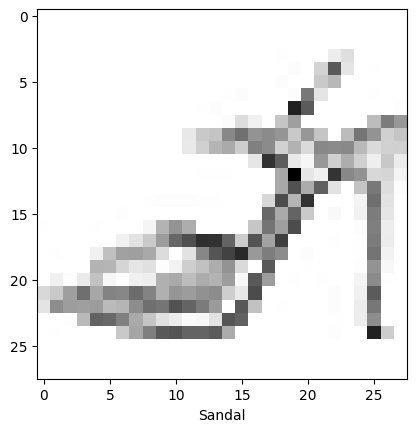

In [5]:
# Displaying a random image from the training set
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [6]:
# Normalizing the pixel values to be between 0 and 1
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

In [7]:
# To increase the diversity of the training data and help prevent overfitting, we can apply data augmentation techniques. 
# This will create variations of the existing images, such as rotations, zooms, and shifts, which can help the model generalize better to unseen data.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1), 
    tf.keras.layers.RandomZoom(0.2),
])

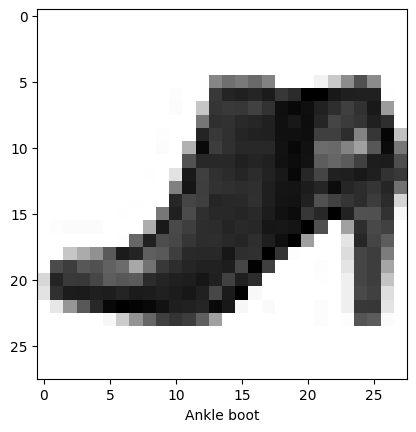

In [8]:
# Displaying a random image from the training set after normalization 
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [9]:
# Displaying the pixel values of the random image
print("pixel_value:")
for row in train_images[rndm]:
    for pixel in row:
        print("{:0.3f}".format(pixel), end=" ")
    print()

pixel_value:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.475 0.565 0.522 0.588 0.490 0.000 0.000 0.000 0.051 0.212 0.45

In [10]:
# Reshape images to (28, 28, 1) to add a channel dimension for the CNN
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [13]:
# Creating CNN model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    #tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,666 (4.16 MB)

 Trainable params: 1,090,666 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Create datasets with augmentation
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [13]:
# Training the CNN model
model.fit(train_images, train_labels, epochs=50, validation_data=(test_images, test_labels))
#model.fit(train_ds, epochs=30, validation_data=test_ds)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.7434 - loss: 0.6866 - val_accuracy: 0.8206 - val_loss: 0.4905
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8240 - loss: 0.4759 - val_accuracy: 0.8532 - val_loss: 0.3951
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.8452 - loss: 0.4163 - val_accuracy: 0.8730 - val_loss: 0.3488
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.8598 - loss: 0.3811 - val_accuracy: 0.8727 - val_loss: 0.3409
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 24ms/step - accuracy: 0.8645 - loss: 0.3666 - val_accuracy: 0.8822 - val_loss: 0.3122
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8716 - loss: 0.3521 - val_accuracy: 0.8815 - val_loss: 0.3256
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8737 - loss: 0.3439 - val_accuracy: 0.8808 - val_loss: 0.3281
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.8758 -

KeyboardInterrupt: 

In [15]:
# Implementing ReduceLROnPlateau and EarlyStopping callbacks

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    epochs=50,
    callbacks=[reduce_lr, early_stop] 
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 24ms/step - accuracy: 0.7375 - loss: 0.6923 - val_accuracy: 0.8111 - val_loss: 0.4935 - learning_rate: 0.0010
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8206 - loss: 0.4816 - val_accuracy: 0.8504 - val_loss: 0.4089 - learning_rate: 0.0010
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8448 - loss: 0.4193 - val_accuracy: 0.8719 - val_loss: 0.3547 - learning_rate: 0.0010
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8566 - loss: 0.3877 - val_accuracy: 0.8793 - val_loss: 0.3255 - learning_rate: 0.0010
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.8644 - loss: 0.3679 - val_accuracy: 0.8787 - val_loss: 0.3262 - learning_rate: 0.0010
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.8728 - loss: 0.3509 - val_accuracy: 0.8857 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accura

In [16]:
# Evaluating the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)   

313/313 - 2s - 6ms/step - accuracy: 0.9168 - loss: 0.2205
Test Loss: 0.22048620879650116
Test Accuracy: 0.9168000221252441


In [17]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [18]:
i = np.random.randint(0, len(test_images))
print("Predicted Label:", np.argmax(predictions[i]))
print("Actual Label:", test_labels[i])

Predicted Label: 1
Actual Label: 1


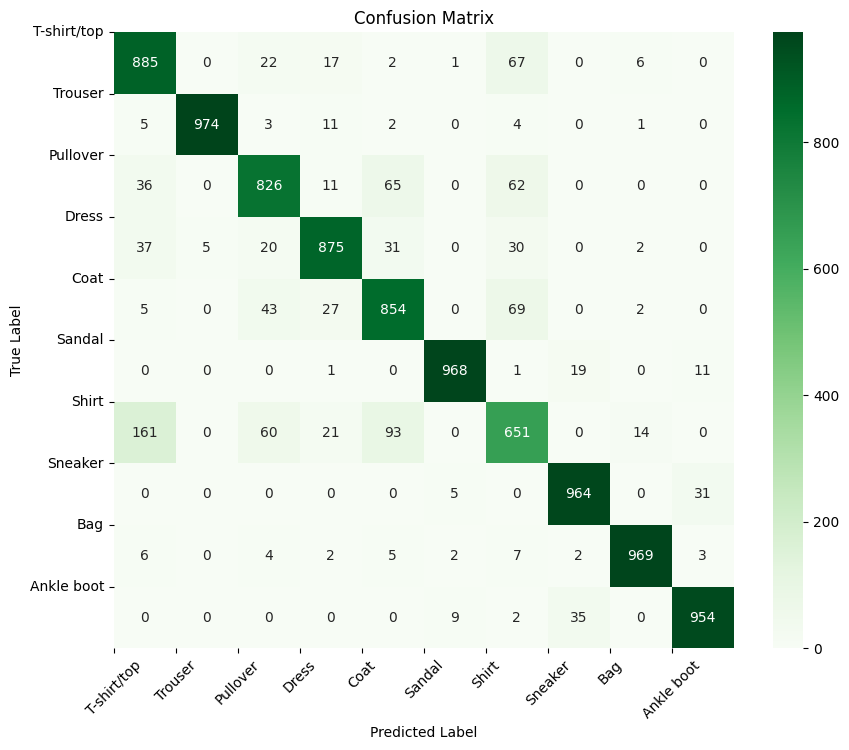

In [ ]:
# Confusion Matrix to better understand the model's performance across different classes
cm = confusion_matrix(test_labels, np.argmax(predictions, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes, rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Saving the trained model for future use
model.save("fashion_mnist_model.keras")